In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

Fir_DIR   = "/content/drive/MyDrive/ZSIVL"
Sec_DIR = "/content/drive/MyDrive/ZSIVL2"

print("SMALL exists:", os.path.exists(Fir_DIR))
print("CAPITAL exists:", os.path.exists(Sec_DIR))

print("SMALL content:", os.listdir(Fir_DIR)[:20] if os.path.exists(Fir_DIR) else "not found")
print("CAPITAL content:", os.listdir(Sec_DIR)[:20] if os.path.exists(Sec_DIR) else "not found")

SMALL exists: True
CAPITAL exists: True
SMALL content: ['American@84Vn2Z.png', 'Democrat@RNQz5q.png', 'Congress@EIxqwy.png']
CAPITAL content: ['American@84Vn2Z.png', 'Democrat@uB9yYk.png', 'Congress@SwIJ9a.png']


In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

SMALL_DIR   = "/content/drive/MyDrive/ZSIVL"
CAPITAL_DIR = "/content/drive/MyDrive/ZSIVL2"

IMG_SIZE = (64, 128)
BATCH = 32
SEED = 42

# 1. Збираємо всі шляхи до png-файлів
small_files = [os.path.join(SMALL_DIR, f) for f in os.listdir(SMALL_DIR) if f.lower().endswith(".png")]
capital_files = [os.path.join(CAPITAL_DIR, f) for f in os.listdir(CAPITAL_DIR) if f.lower().endswith(".png")]

all_files = small_files + capital_files

print("К-сть Fir:", len(small_files))
print("К-сть Sec:", len(capital_files))
print("Всього файлів:", len(all_files))

# 2. Дістаємо назву класу з імені файлу (до символу @)
def extract_label(filepath):
    filename = os.path.basename(filepath)
    return filename.split("@")[0]

all_labels_text = [extract_label(path) for path in all_files]

# 3. Створюємо список унікальних класів
class_names = sorted(list(set(all_labels_text)))
num_classes = len(class_names)

print("Класи:", class_names)
print("К-сть класів:", num_classes)

# 4. Мапимо текстові labels у числа
label_to_index = {label: idx for idx, label in enumerate(class_names)}
all_labels = [label_to_index[label] for label in all_labels_text]

# 5. Перемішуємо
rng = np.random.default_rng(SEED)
indices = np.arange(len(all_files))
rng.shuffle(indices)

all_files = np.array(all_files)[indices]
all_labels = np.array(all_labels)[indices]

# 6. Функція завантаження і підготовки картинки
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

# 7. Створюємо tf.data.Dataset
dataset = tf.data.Dataset.from_tensor_slices((all_files, all_labels))
dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

# 8. Ділимо на train/val
dataset_size = len(all_files)
train_size = int(0.8 * dataset_size)

train_ds = dataset.take(train_size).batch(BATCH).prefetch(tf.data.AUTOTUNE)
val_ds = dataset.skip(train_size).batch(BATCH).prefetch(tf.data.AUTOTUNE)

print("Train size:", train_size)
print("Val size:", dataset_size - train_size)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
К-сть Fir: 3
К-сть Sec: 3
Всього файлів: 6
Класи: ['American', 'Congress', 'Democrat']
К-сть класів: 3
Train size: 4
Val size: 2


In [7]:
# train / val / test split
dataset_size = len(all_files)

n_train = int(0.7 * dataset_size)
n_val   = int(0.15 * dataset_size)
n_test  = dataset_size - n_train - n_val

train_ds = dataset.take(n_train)
temp_ds  = dataset.skip(n_train)
val_ds   = temp_ds.take(n_val)
test_ds  = temp_ds.skip(n_val)

# batching
BATCH = 32

train_ds = train_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

print("train:", n_train, "val:", n_val, "test:", n_test)

train: 4 val: 0 test: 2


In [8]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64, 128, 3)),

    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 126, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 14, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,376,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,470,019 (5.61 MB)

 Trainable params: 1,470,019 (5.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8
)

Epoch 1/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2500 - loss: 1.1899
Epoch 2/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.5000 - loss: 1.2554


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Epoch 3/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 1.0000 - loss: 0.8524
Epoch 4/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 1.0000 - loss: 0.6781
Epoch 5/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.7500 - loss: 0.5920
Epoch 6/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7500 - loss: 0.4539
Epoch 7/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 1.0000 - loss: 0.2776
Epoch 8/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 1.0000 - loss: 0.1916


In [10]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print("\ntest точність:", round(float(test_acc), 4))


test точність: 0.5


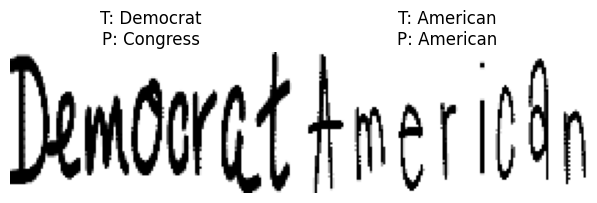

In [11]:
images, labels = next(iter(test_ds))
pred = model.predict(images, verbose=0)
pred_ids = np.argmax(pred, axis=1)

plt.figure(figsize=(12, 4))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy())
    t = class_names[int(labels[i].numpy())]
    p = class_names[int(pred_ids[i])]
    plt.title(f"T: {t}\nP: {p}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:

!git clone https://github.com/maruunaa/ZSIiL.git

Cloning into 'ZSIiL'...
